In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TEM12 is a CSV file
tem12 = pd.read_csv('TEM12.20260312T150343.csv')
print(tem12.shape)
print(tem12.head(20))
print(tem12.columns.tolist())

(16080, 6)
                             Statistic Label         Month  \
0   New Vehicles Licensed for the First Time  2015 January   
1   New Vehicles Licensed for the First Time  2015 January   
2   New Vehicles Licensed for the First Time  2015 January   
3   New Vehicles Licensed for the First Time  2015 January   
4   New Vehicles Licensed for the First Time  2015 January   
5   New Vehicles Licensed for the First Time  2015 January   
6   New Vehicles Licensed for the First Time  2015 January   
7   New Vehicles Licensed for the First Time  2015 January   
8   New Vehicles Licensed for the First Time  2015 January   
9   New Vehicles Licensed for the First Time  2015 January   
10  New Vehicles Licensed for the First Time  2015 January   
11  New Vehicles Licensed for the First Time  2015 January   
12  New Vehicles Licensed for the First Time  2015 January   
13  New Vehicles Licensed for the First Time  2015 January   
14  New Vehicles Licensed for the First Time  2015 January 

In [3]:
# Search for EV/electric related rows
print(tem12[tem12.astype(str).apply(
    lambda x: x.str.contains('electric|Electric|BEV|EV|Elect', na=False)
).any(axis=1)])

                                Statistic Label          Month  \
4      New Vehicles Licensed for the First Time   2015 January   
5      New Vehicles Licensed for the First Time   2015 January   
6      New Vehicles Licensed for the First Time   2015 January   
7      New Vehicles Licensed for the First Time   2015 January   
12     New Vehicles Licensed for the First Time   2015 January   
...                                         ...            ...   
16071  New Vehicles Licensed for the First Time  2026 February   
16076  New Vehicles Licensed for the First Time  2026 February   
16077  New Vehicles Licensed for the First Time  2026 February   
16078  New Vehicles Licensed for the First Time  2026 February   
16079  New Vehicles Licensed for the First Time  2026 February   

           Type of Vehicle Registration  \
4                          All Vehicles   
5                          All Vehicles   
6                          All Vehicles   
7                          All Vehi

In [4]:
cpm12 = pd.read_csv('CPM12.20260312T150355.csv')
print(cpm12.shape)
print(cpm12.head(20))
print(cpm12.columns.tolist())

(12996, 5)
           STATISTIC Label          Month  \
0   National Average Price  2011 December   
1   National Average Price  2011 December   
2   National Average Price  2011 December   
3   National Average Price  2011 December   
4   National Average Price  2011 December   
5   National Average Price  2011 December   
6   National Average Price  2011 December   
7   National Average Price  2011 December   
8   National Average Price  2011 December   
9   National Average Price  2011 December   
10  National Average Price  2011 December   
11  National Average Price  2011 December   
12  National Average Price  2011 December   
13  National Average Price  2011 December   
14  National Average Price  2011 December   
15  National Average Price  2011 December   
16  National Average Price  2011 December   
17  National Average Price  2011 December   
18  National Average Price  2011 December   
19  National Average Price  2011 December   

                            Consumer Item  

In [5]:
nta47 = pd.read_excel('NTA47.20260506T100500.xlsx')
print(nta47.shape)
print(nta47.head(20))
print(nta47.columns.tolist())

(38, 2)
      Unnamed: 0                                         Unnamed: 1
0            NaN                                                NaN
1            NaN                                                NaN
2            NaN                                                NaN
3            NaN                                                NaN
4            NaN                                                NaN
5            NaN                                                NaN
6          Table                                                NaN
7           Code                                              NTA47
8           Name  Factors that influenced the purchase of an Ele...
9      Frequency                                             Annual
10  Last Updated                                01/07/2022 11:00:00
11          Note  Respondents may have selected more than one op...
12           Url  https://ws.cso.ie/public/api.restful/PxStat.Da...
13           NaN                        

In [11]:
# Filter to New Private Cars + Electric fuel type only
ev_monthly = tem12[
    (tem12['Type of Vehicle Registration'] == 'New Private Cars') &
    (tem12['Type of Fuel'] == 'Electric')
].copy()

print(ev_monthly.shape)
print(ev_monthly.head(20))
print(ev_monthly['Month'].unique()[:24])

(134, 6)
                               Statistic Label           Month  \
13    New Vehicles Licensed for the First Time    2015 January   
133   New Vehicles Licensed for the First Time   2015 February   
253   New Vehicles Licensed for the First Time      2015 March   
373   New Vehicles Licensed for the First Time      2015 April   
493   New Vehicles Licensed for the First Time        2015 May   
613   New Vehicles Licensed for the First Time       2015 June   
733   New Vehicles Licensed for the First Time       2015 July   
853   New Vehicles Licensed for the First Time     2015 August   
973   New Vehicles Licensed for the First Time  2015 September   
1093  New Vehicles Licensed for the First Time    2015 October   
1213  New Vehicles Licensed for the First Time   2015 November   
1333  New Vehicles Licensed for the First Time   2015 December   
1453  New Vehicles Licensed for the First Time    2016 January   
1573  New Vehicles Licensed for the First Time   2016 February   
1

In [13]:
# Convert Month column (e.g. "2015 January") to datetime
ev_monthly['date'] = pd.to_datetime(ev_monthly['Month'], format='%Y %B')
ev_monthly = ev_monthly.sort_values('date').reset_index(drop=True)

# Keep only date and value
ev_monthly = ev_monthly[['date', 'VALUE']].rename(columns={'VALUE': 'ev_registrations'})

print(ev_monthly.head(12))
print(f'Total months: {len(ev_monthly)}')
print(f'Date range: {ev_monthly.date.min()} to {ev_monthly.date.max()}')

         date  ev_registrations
0  2015-01-01              68.0
1  2015-02-01              72.0
2  2015-03-01              56.0
3  2015-04-01              72.0
4  2015-05-01              36.0
5  2015-06-01              13.0
6  2015-07-01              61.0
7  2015-08-01              49.0
8  2015-09-01              26.0
9  2015-10-01              11.0
10 2015-11-01               9.0
11 2015-12-01               3.0
Total months: 134
Date range: 2015-01-01 00:00:00 to 2026-02-01 00:00:00


In [15]:
# Check CPM12 structure first
print(cpm12.head(20))
print(cpm12.columns.tolist())
print(cpm12['Type of Fuel'].unique() if 'Type of Fuel' in cpm12.columns else cpm12.iloc[:,2].unique())

           STATISTIC Label          Month  \
0   National Average Price  2011 December   
1   National Average Price  2011 December   
2   National Average Price  2011 December   
3   National Average Price  2011 December   
4   National Average Price  2011 December   
5   National Average Price  2011 December   
6   National Average Price  2011 December   
7   National Average Price  2011 December   
8   National Average Price  2011 December   
9   National Average Price  2011 December   
10  National Average Price  2011 December   
11  National Average Price  2011 December   
12  National Average Price  2011 December   
13  National Average Price  2011 December   
14  National Average Price  2011 December   
15  National Average Price  2011 December   
16  National Average Price  2011 December   
17  National Average Price  2011 December   
18  National Average Price  2011 December   
19  National Average Price  2011 December   

                            Consumer Item  UNIT  VALUE

In [17]:
# Find the exact fuel-related item names
fuel_items = cpm12[cpm12['Consumer Item'].str.contains(
    'Diesel|Petrol|litre', na=False
)]
print(fuel_items['Consumer Item'].unique())
print(fuel_items.head(20))

['Full fat milk per 2 litre' 'Low fat milk per 1 litre'
 'Orange juice per litre' 'Diesel per litre' 'Petrol - unleaded per litre']
            STATISTIC Label          Month                Consumer Item  UNIT  \
26   National Average Price  2011 December    Full fat milk per 2 litre  Euro   
27   National Average Price  2011 December     Low fat milk per 1 litre  Euro   
47   National Average Price  2011 December       Orange juice per litre  Euro   
69   National Average Price  2011 December             Diesel per litre  Euro   
70   National Average Price  2011 December  Petrol - unleaded per litre  Euro   
102  National Average Price   2012 January    Full fat milk per 2 litre  Euro   
103  National Average Price   2012 January     Low fat milk per 1 litre  Euro   
123  National Average Price   2012 January       Orange juice per litre  Euro   
145  National Average Price   2012 January             Diesel per litre  Euro   
146  National Average Price   2012 January  Petrol - unlea

In [19]:
# Filter to petrol and diesel only, average them per month
fuel_monthly = cpm12[cpm12['Consumer Item'].str.contains(
    'Diesel per litre|Petrol - unleaded per litre', na=False
)].copy()

fuel_monthly['date'] = pd.to_datetime(fuel_monthly['Month'], format='%Y %B')
fuel_monthly = fuel_monthly.groupby('date')['VALUE'].mean().reset_index()
fuel_monthly.columns = ['date', 'fuel_price']
fuel_monthly = fuel_monthly.sort_values('date').reset_index(drop=True)

print(fuel_monthly.head(12))
print(f'Total months: {len(fuel_monthly)}')
print(f'Date range: {fuel_monthly.date.min()} to {fuel_monthly.date.max()}')

         date  fuel_price
0  2011-12-01         NaN
1  2012-01-01      1.5355
2  2012-02-01      1.5660
3  2012-03-01      1.6055
4  2012-04-01      1.6430
5  2012-05-01      1.6220
6  2012-06-01      1.5775
7  2012-07-01      1.5515
8  2012-08-01      1.6090
9  2012-09-01      1.6580
10 2012-10-01      1.6345
11 2012-11-01      1.5885
Total months: 171
Date range: 2011-12-01 00:00:00 to 2026-02-01 00:00:00


In [21]:
# Merge on date
monthly_df = pd.merge(ev_monthly, fuel_monthly, on='date', how='inner')

# Add year and month as numeric features
monthly_df['year'] = monthly_df['date'].dt.year
monthly_df['month'] = monthly_df['date'].dt.month

# Forward fill grant values by year
grant_map = {
    2015: 5000, 2016: 5000, 2017: 5000, 2018: 5000,
    2019: 5000, 2020: 5000, 2021: 5000, 2022: 5000,
    2023: 3500, 2024: 3500, 2025: 3500, 2026: 3500
}
monthly_df['grant_value'] = monthly_df['year'].map(grant_map)

print(monthly_df.head(12))
print(f'Final dataset shape: {monthly_df.shape}')
print(monthly_df.isnull().sum())

         date  ev_registrations  fuel_price  year  month  grant_value
0  2015-01-01              68.0      1.2635  2015      1         5000
1  2015-02-01              72.0      1.2590  2015      2         5000
2  2015-03-01              56.0      1.3290  2015      3         5000
3  2015-04-01              72.0      1.3490  2015      4         5000
4  2015-05-01              36.0      1.3890  2015      5         5000
5  2015-06-01              13.0      1.3945  2015      6         5000
6  2015-07-01              61.0      1.3875  2015      7         5000
7  2015-08-01              49.0      1.3520  2015      8         5000
8  2015-09-01              26.0      1.2920  2015      9         5000
9  2015-10-01              11.0      1.2590  2015     10         5000
10 2015-11-01               9.0      1.2560  2015     11         5000
11 2015-12-01               3.0      1.2445  2015     12         5000
Final dataset shape: (134, 6)
date                0
ev_registrations    0
fuel_price      

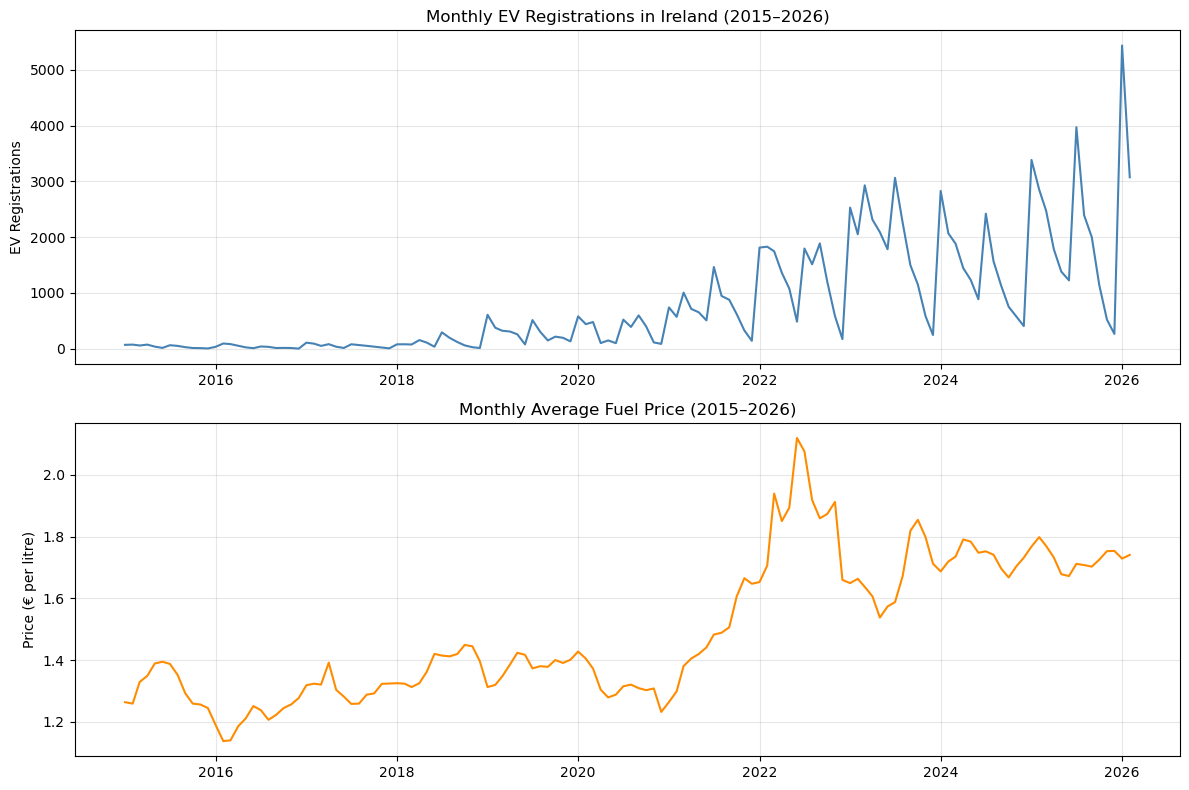

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(monthly_df['date'], monthly_df['ev_registrations'], color='steelblue')
ax1.set_title('Monthly EV Registrations in Ireland (2015–2026)')
ax1.set_ylabel('EV Registrations')
ax1.grid(True, alpha=0.3)

ax2.plot(monthly_df['date'], monthly_df['fuel_price'], color='darkorange')
ax2.set_title('Monthly Average Fuel Price (2015–2026)')
ax2.set_ylabel('Price (€ per litre)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

# Features and target
X1 = monthly_df[['fuel_price']]
X2 = monthly_df[['fuel_price', 'year']]
X3 = monthly_df[['fuel_price', 'year', 'grant_value']]
X4 = monthly_df[['fuel_price', 'year', 'month', 'grant_value']]
y  = monthly_df['ev_registrations']

results = []

for label, X in [('Model 1 - LR fuel_price', X1),
                 ('Model 2 - LR + year', X2),
                 ('Model 3 - LR + grant', X3),
                 ('Model 4 - LR + month', X4)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5, scoring='r2')
    results.append({
        'Model': label,
        'R²': round(r2, 3),
        'MSE': round(mse, 0),
        'CV Mean R²': round(cv.mean(), 3),
        'CV Std': round(cv.std(), 3)
    })
    print(f'{label}: R²={r2:.3f}, MSE={mse:,.0f}, CV R²={cv.mean():.3f} ± {cv.std():.3f}')

Model 1 - LR fuel_price: R²=0.608, MSE=279,846, CV R²=-15.516 ± 26.873
Model 2 - LR + year: R²=0.808, MSE=137,008, CV R²=-112.474 ± 223.156
Model 3 - LR + grant: R²=0.877, MSE=87,793, CV R²=-68.059 ± 135.623
Model 4 - LR + month: R²=0.874, MSE=90,224, CV R²=-52.676 ± 102.920


Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest: R²=0.913, MSE=62,476
CV R²=0.142 ± 0.402


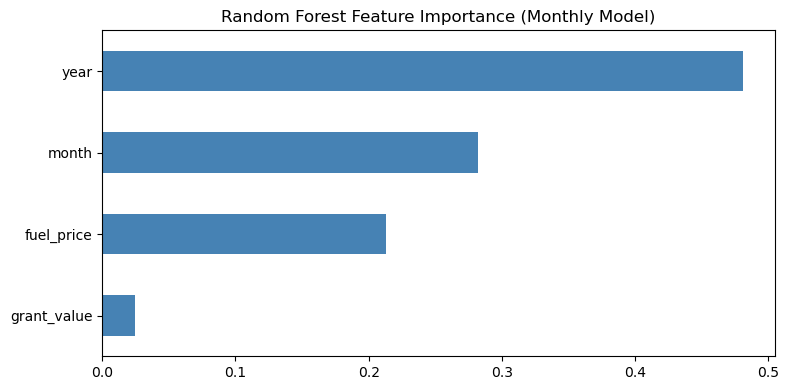

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X4, y, test_size=0.2, random_state=42
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
cv_rf = cross_val_score(best_rf, X4, y, cv=5, scoring='r2')

print(f'Best params: {grid.best_params_}')
print(f'Random Forest: R²={r2_rf:.3f}, MSE={mse_rf:,.0f}')
print(f'CV R²={cv_rf.mean():.3f} ± {cv_rf.std():.3f}')

results.append({
    'Model': 'Model 5 - Random Forest',
    'R²': round(r2_rf, 3),
    'MSE': round(mse_rf, 0),
    'CV Mean R²': round(cv_rf.mean(), 3),
    'CV Std': round(cv_rf.std(), 3)
})

# Feature importance
importances = pd.Series(best_rf.feature_importances_, index=X4.columns)
importances.sort_values().plot(kind='barh', figsize=(8,4), color='steelblue')
plt.title('Random Forest Feature Importance (Monthly Model)')
plt.tight_layout()
plt.savefig('monthly_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                  Model    R²      MSE  CV Mean R²  CV Std
Model 1 - LR fuel_price 0.608 279846.0     -15.516  26.873
    Model 2 - LR + year 0.808 137008.0    -112.474 223.156
   Model 3 - LR + grant 0.877  87793.0     -68.059 135.623
   Model 4 - LR + month 0.874  90224.0     -52.676 102.920
Model 5 - Random Forest 0.913  62476.0       0.142   0.402


# Summary comment for exploration notebook
"""
EXPLORATION FINDINGS — Monthly Dataset Analysis

Test R² scores appeared strong (0.61–0.91) but cross-validation 
revealed severe overfitting across all linear models (CV R² as low as -112).

Root cause: EV adoption follows a strong exponential time trend.
Cross-validation splits break this temporal dependency, exposing 
that the models are learning the time trend rather than genuine 
relationships between fuel price, grants, and EV adoption.

Only Random Forest showed positive CV R² (0.142) but with high 
variance (±0.402), indicating instability.

Conclusion: Monthly granularity introduces seasonal noise and 
overfitting risk that outweighs the benefit of additional observations.
The annual model with honest limitation discussion remains the 
more academically defensible approach.

This exploration file is retained as evidence of iterative 
analysis and critical model evaluation.
"""
print("Exploration complete — see summary above")